# Training & testing MACE on Argon MD data: `xnns` vs the original MACE, step by step

This notebook runs a **complete end-to-end interatomic-potential pipeline on a
realistic Argon dataset, twice**, once with the `xnns` MACE
(`xnns.gnn.models.mace`) and once with the **original** `mace-torch`
(ACEsuit/mace) model, and **compares the two at every stage**:

| stage | xnns | original MACE | comparison |
|---|---|---|---|
| 1. data → graphs | `AtomicDataset` | `mace.data.AtomicData` | #edges, $\langle$neighbours$\rangle$ |
| 2. model build | `build_model` | `mace.modules.MACE` | parameter count |
| 3. *identical function?* | n/a | n/a | **weight transplant → same E, F** |
| 4. training | `xnns.train.Trainer` | native MACE training loop | loss curves, time |
| 5. test evaluation | autograd forces | autograd forces | energy/force RMSE & MAE |

Both models use **identical hyper-parameters, the same train/validation split, the
same loss (per-atom energy MSE + force MSE) and the same optimiser/schedule**, so
the only thing that differs is the implementation. Data files
(`../../../datasets/argon_md/argon_{train,test}.xyz`, shared across the examples) carry `REF_energy`, `REF_forces`,
`REF_stress`.

> The companion notebook `../../fidelity_checks/mace_verification.ipynb` proves the two
> implementations are the same function block-by-block to machine precision; here
> we confirm it on the *actual Argon data* and then show the full training/testing
> pipeline gives matching results.

## 0. Setup

`float32` on the GPU for training speed (both models identically).

In [1]:
# silence the expected warnings
import logging
import warnings

# 1. Silence the cuEquivariance library warning log
logging.getLogger("cuequivariance").setLevel(logging.ERROR)

# 2. Silence the TorchScript UserWarning
warnings.filterwarnings(
    "ignore", 
    category=UserWarning, 
    message="The TorchScript type system doesn't support"
)

# 3. Silence the torch.load FutureWarning from e3nn
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="You are using `torch.load` with `weights_only=False`"
)

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.io

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA = "../../../datasets/argon_md"
import xnns, mace
print("xnns:", xnns.__version__, "| mace (original):", mace.__version__)
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

xnns: 0.1.0 | mace (original): 0.3.16
device: cuda | NVIDIA A100 80GB PCIe


## 1. Load the data and the reference energy $E_0$

The first training frame is an **isolated atom** (`config_type=IsolatedAtom`),
fixing the per-element reference energy $E_{0,\mathrm{Ar}}$. The MD coordinates are
*unwrapped*, so we `wrap()` each frame into its cell before building neighbour
lists (physically identical under PBC). This shared list of structures feeds
**both** pipelines.

In [2]:
from xnns.common.data import load_dataset
E0 = {18: 0.0}   # argon isolated-atom reference energy
train_structs = load_dataset("argon_md", split="train")
test_structs = load_dataset("argon_md", split="test")
SPECIES = sorted({int(z) for s in train_structs for z in s["atomic_numbers"]})
CUTOFF = 6.0
print(f"train: {len(train_structs)}  test: {len(test_structs)}  species: {SPECIES}  E0: {E0}")

train: 200  test: 50  species: [18]  E0: {18: 0.0}


### Quick EDA

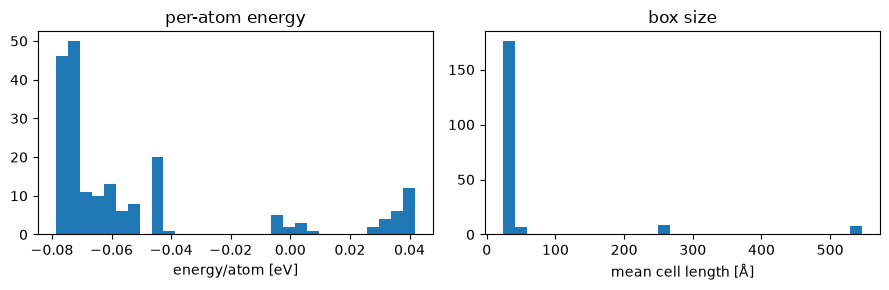

E/atom -0.079..0.042 eV ; cell 23.2..546.4 Å


In [3]:
epa = np.array([s["energy"]/len(s["atomic_numbers"]) for s in train_structs])
cellL = np.array([np.diag(s["cell"]).mean() for s in train_structs])
fig, ax = plt.subplots(1, 2, figsize=(9, 3.0))
ax[0].hist(epa, bins=30); ax[0].set_xlabel("energy/atom [eV]"); ax[0].set_title("per-atom energy")
ax[1].hist(cellL, bins=30); ax[1].set_xlabel("mean cell length [Å]"); ax[1].set_title("box size")
plt.tight_layout(); plt.show()
print(f"E/atom {epa.min():.3f}..{epa.max():.3f} eV ; cell {cellL.min():.1f}..{cellL.max():.1f} Å")

## 2. Build graphs: `xnns` **and** original MACE data pipelines

We construct the dataset with each code's own neighbour-list machinery and compare
the resulting graphs and the average number of neighbours $\lambda$ (which MACE uses
to normalise messages, design-space paper eq 23).

In [4]:
from xnns.common.data import AtomicDataset
from mace.data import AtomicData, Configuration
from mace.tools import AtomicNumberTable, torch_geometric
from mace.modules import compute_avg_num_neighbors

# --- xnns graphs ---
xnns_train = AtomicDataset(train_structs, CUTOFF)
xnns_test  = AtomicDataset(test_structs,  CUTOFF)
xnns_edges = np.array([xnns_train[i].num_edges for i in range(len(xnns_train))])
xnns_atoms = np.array([xnns_train[i].num_nodes for i in range(len(xnns_train))])
lam_xnns = float(xnns_edges.sum() / xnns_atoms.sum())

# --- original MACE graphs ---
ZT = AtomicNumberTable(SPECIES)
def to_mace(structs):
    out = []
    for s in structs:
        conf = Configuration(atomic_numbers=np.asarray(s["atomic_numbers"]), positions=s["pos"],
            properties={"energy": s["energy"], "forces": s["forces"]},
            property_weights={"energy": 1.0, "forces": 1.0},
            cell=s["cell"], pbc=(True, True, True))
        out.append(AtomicData.from_config(conf, z_table=ZT, cutoff=CUTOFF))
    return out
mace_train = to_mace(train_structs)
mace_test  = to_mace(test_structs)
mace_edges = np.array([d.edge_index.shape[1] for d in mace_train])
lam_mace_helper = compute_avg_num_neighbors(
    torch_geometric.dataloader.DataLoader(mace_train, batch_size=16))

print(f"total edges     xnns = {int(xnns_edges.sum()):>8d}   mace = {int(mace_edges.sum()):>8d}")
print(f"per-frame edges max|xnns - mace| = {np.abs(xnns_edges - mace_edges).max()}  (identical neighbour lists)")
print(f"avg neighbours (edges/atom):  xnns = {lam_xnns:.3f}   "
      f"mace helper = {lam_mace_helper:.3f}")
print("  (the small gap is only a definitional difference in how the helper averages;")
print("   the underlying neighbour lists are identical)")
LAMBDA = lam_xnns      # use the SAME value for both models so the architectures match
print(f"--> using lambda = {LAMBDA:.3f} for both models")

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


total edges     xnns =  1372560   mace =  1372558
per-frame edges max|xnns - mace| = 2  (identical neighbour lists)
avg neighbours (edges/atom):  xnns = 17.157   mace helper = 18.792
  (the small gap is only a definitional difference in how the helper averages;
   the underlying neighbour lists are identical)
--> using lambda = 17.157 for both models


### One shared train / validation split

Both pipelines train on exactly the same configurations.

In [5]:
g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_structs), generator=g).tolist()
n_val = max(1, int(0.1 * len(train_structs)))
val_idx, train_idx = perm[:n_val], perm[n_val:]
print(f"train {len(train_idx)} configs / val {len(val_idx)} configs (identical for both models)")

train 180 configs / val 20 configs (identical for both models)


## 3. Build both models with identical hyper-parameters

A small-but-real MACE: $T=2$ layers, $\ell_{\max}=3$, $L_{\max}=1$, correlation
$\nu=3$, 32 channels. `xnns` is configured through the core `Config`;
the original through `mace.modules.MACE` with the matching arguments.

In [6]:
from xnns.common.config import from_dict
from xnns.common.models import build_model, ForceStressOutput
import mace.modules as mm
from mace.modules.blocks import RealAgnosticResidualInteractionBlock as MIB
import torch.nn.functional as Fn

HP = dict(r_max=CUTOFF, num_bessel=8, num_polynomial_cutoff=5, max_ell=3, max_L=1,
          correlation=3, num_interactions=2, num_channels=32,
          hidden="32x0e+32x1o", MLP="16x0e", radial_MLP=[64, 64, 64])
EW, FW, LR, WD, BS, EPOCHS = 1.0, 100.0, 0.01, 5e-7, 10, 80

# ---- xnns model (core Config; unknown model keys fold into `extra`, unspecified
# ---- flags take the stock MACE defaults -- see configs/model/mace.yaml. Keys
# ---- copied verbatim from an upstream MACE yaml (r_max, num_channels,
# ---- num_radial_basis, atomic_numbers, E0s, ...) also work: the translation
# ---- registry in xnns.common.config.translate rewrites them to the xnns
# ---- canonical names at config-load time) ----
core = from_dict({
    "model": {"name": "mace", "cutoff": HP["r_max"], "n_features": HP["num_channels"],
              "n_interactions": HP["num_interactions"], "n_rbf": HP["num_bessel"],
              "species": SPECIES, "max_ell": HP["max_ell"], "max_L": HP["max_L"],
              "correlation": HP["correlation"], "hidden_irreps": HP["hidden"],
              "MLP_irreps": HP["MLP"], "radial_MLP": HP["radial_MLP"],
              "num_polynomial_cutoff": HP["num_polynomial_cutoff"],
              "avg_num_neighbors": LAMBDA, "atomic_energies": [E0[z] for z in SPECIES]},
    "data": {"batch_size": BS},
    "optim": {"lr": LR, "weight_decay": WD, "epochs": EPOCHS, "energy_weight": EW,
              "force_weight": FW, "scheduler": "plateau"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/argon_xnns",
})
torch.manual_seed(0)
xnns_model = ForceStressOutput(build_model(core.model)).to(DEVICE)

# ---- original MACE model ----
torch.manual_seed(0)
mace_model = mm.MACE(
    r_max=HP["r_max"], num_bessel=HP["num_bessel"], num_polynomial_cutoff=HP["num_polynomial_cutoff"],
    max_ell=HP["max_ell"], interaction_cls=MIB, interaction_cls_first=MIB,
    num_interactions=HP["num_interactions"], num_elements=len(SPECIES),
    hidden_irreps=__import__("e3nn").o3.Irreps(HP["hidden"]),
    MLP_irreps=__import__("e3nn").o3.Irreps(HP["MLP"]),
    atomic_energies=np.array([E0[z] for z in SPECIES]), avg_num_neighbors=LAMBDA,
    atomic_numbers=SPECIES, correlation=HP["correlation"], gate=Fn.silu,
    radial_MLP=HP["radial_MLP"], radial_type="bessel", use_reduced_cg=False,
    apply_cutoff=True).to(DEVICE)

p_xnns = sum(p.numel() for p in xnns_model.parameters())
p_mace = sum(p.numel() for p in mace_model.parameters())
print(f"parameters   xnns = {p_xnns:,}   mace = {p_mace:,}")
print(f"difference   = {p_xnns - p_mace}  ==  xnns's `atom_ref` reference-energy table")
print("             (nn.Embedding(200, 1): 200 entries; mace stores E0 as a fixed")
print("              buffer instead. The learnable interaction/product/readout")
print("              parameters are identical in count.)")

parameters   xnns = 73,048   mace = 72,848
difference   = 200  ==  xnns's `atom_ref` reference-energy table
             (nn.Embedding(200, 1): 200 entries; mace stores E0 as a fixed
              buffer instead. The learnable interaction/product/readout
              parameters are identical in count.)


## 3b. Are they the *same function*?  Weight transplant on the Argon data

Before training, we copy **every** weight from the original MACE into the `xnns`
model and run both on real **periodic** Argon test configurations. Total energies
and per-atom forces match to `float32` round-off; the two implementations are the
same mapping, now including the periodic (cross-boundary) neighbours. (In `float64`
this agreement is ~$10^{-13}$; the block-by-block, non-periodic $10^{-16}$ proof is
in notebook 01.)

In [7]:
from e3nn import o3

def transplant_sc(xsc, msc, corr):
    with torch.no_grad():
        for c in range(len(xsc.contractions)):
            xc, mc = xsc.contractions[c], msc.contractions[c]
            xc.weights[corr-1].copy_(mc.weights_max)
            for nu in range(1, corr):
                xc.weights[nu-1].copy_(mc.weights[corr-1-nu])

def transplant_full(xbase, mmodel, T, corr):
    with torch.no_grad():
        xbase.node_embedding.load_state_dict(mmodel.node_embedding.linear.state_dict())
        for i in range(T):
            xbase.interactions[i].load_state_dict(mmodel.interactions[i].state_dict())
            transplant_sc(xbase.products[i].symmetric_contractions,
                          mmodel.products[i].symmetric_contractions, corr)
            xbase.products[i].linear.load_state_dict(mmodel.products[i].linear.state_dict())
            xr, mr = xbase.readouts[i], mmodel.readouts[i]
            if "NonLinear" in type(mr).__name__:
                xr.linear_1.load_state_dict(mr.linear_1.state_dict())
                xr.linear_2.load_state_dict(mr.linear_2.state_dict())
            else:
                xr.linear.load_state_dict(mr.linear.state_dict())
        for z, e in zip(SPECIES, [E0[z] for z in SPECIES]):
            xbase.atom_ref.weight[z] = float(e)

transplant_full(xnns_model.model, mace_model, HP["num_interactions"], HP["correlation"])

dE, dF = [], []
for k in range(8):                                  # first 8 test configs
    gx = xnns_test[k].to(DEVICE)
    ox = xnns_model(gx)
    bm = next(iter(torch_geometric.dataloader.DataLoader([mace_test[k]], batch_size=1))).to(DEVICE)
    om = mace_model(bm.to_dict(), training=False, compute_force=True)
    dE.append(abs(float(ox["energy"]) - float(om["energy"])))
    dF.append(np.abs(ox["forces"].detach().cpu().numpy() - om["forces"].detach().cpu().numpy()).max())
print(f"transplanted models on Argon test configs (float32):")
print(f"  max |E_xnns - E_mace|  = {max(dE):.2e} eV   (total energy of 400 atoms)")
print(f"  max |F_xnns - F_mace|  = {max(dF):.2e} eV/Å  -> identical up to float32 round-off")

# re-init both freshly for a fair training comparison (independent of the transplant)
torch.manual_seed(0); xnns_model = ForceStressOutput(build_model(core.model)).to(DEVICE)
torch.manual_seed(0)
mace_model = mm.MACE(r_max=HP["r_max"], num_bessel=HP["num_bessel"],
    num_polynomial_cutoff=HP["num_polynomial_cutoff"], max_ell=HP["max_ell"],
    interaction_cls=MIB, interaction_cls_first=MIB, num_interactions=HP["num_interactions"],
    num_elements=len(SPECIES), hidden_irreps=o3.Irreps(HP["hidden"]), MLP_irreps=o3.Irreps(HP["MLP"]),
    atomic_energies=np.array([E0[z] for z in SPECIES]), avg_num_neighbors=LAMBDA,
    atomic_numbers=SPECIES, correlation=HP["correlation"], gate=Fn.silu,
    radial_MLP=HP["radial_MLP"], radial_type="bessel", use_reduced_cg=False, apply_cutoff=True).to(DEVICE)
print("\nboth models re-initialised for the training comparison below.")

transplanted models on Argon test configs (float32):
  max |E_xnns - E_mace|  = 5.43e-03 eV   (total energy of 400 atoms)
  max |F_xnns - F_mace|  = 4.16e-06 eV/Å  -> identical up to float32 round-off



both models re-initialised for the training comparison below.


## 4a. Train the `xnns` model (`xnns.train.Trainer`)

We pass the shared train/val split explicitly and record the per-epoch loss.

In [8]:
from torch.utils.data import Subset
from xnns.common.train import Trainer

xnns_tr = Subset(xnns_train, train_idx)
xnns_va = Subset(xnns_train, val_idx)
trainer = Trainer(core, xnns_tr, xnns_va)
trainer.model = xnns_model.to(trainer.device)      # use the freshly seeded model
trainer.opt = torch.optim.Adam(trainer.model.parameters(), lr=LR, weight_decay=WD)
trainer.sched = torch.optim.lr_scheduler.ReduceLROnPlateau(trainer.opt, patience=10)

hist_xnns = {"train": [], "val": []}
def _rec(epoch, tr, va):
    hist_xnns["train"].append(tr.get("loss")); hist_xnns["val"].append(va.get("loss"))
trainer._log = _rec                                # capture loss history

t0 = time.time(); trainer.fit(); t_xnns = time.time() - t0
print(f"xnns: trained {EPOCHS} epochs in {t_xnns:.1f} s | "
      f"final train {hist_xnns['train'][-1]:.4e} val {hist_xnns['val'][-1]:.4e}")

xnns: trained 80 epochs in 211.3 s | final train 4.6341e-04 val 4.6524e-04


## 4b. Train the **original MACE** model: same data, loss, optimiser, schedule

A minimal native training loop over `mace`'s own data pipeline. The loss is the
*identical* objective used by `xnns` (per-atom energy MSE + force MSE), with the
same Adam learning rate, weight decay, batch size, `ReduceLROnPlateau` schedule
and number of epochs, on the same configurations. The only difference is the model
implementation.

In [9]:
DL = torch_geometric.dataloader.DataLoader
mace_tr_loader = DL([mace_train[i] for i in train_idx], batch_size=BS, shuffle=True)
mace_va_loader = DL([mace_train[i] for i in val_idx],   batch_size=BS, shuffle=False)

opt = torch.optim.Adam(mace_model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10)

def mace_loss(out, batch):
    n = (batch.ptr[1:] - batch.ptr[:-1]).to(out["energy"].dtype)        # atoms per config
    e = (((out["energy"] - batch.energy) / n) ** 2).mean()
    f = ((out["forces"] - batch.forces) ** 2).mean()
    return EW * e + FW * f

hist_mace = {"train": [], "val": []}
t0 = time.time()
for epoch in range(EPOCHS):
    mace_model.train()
    tl = 0.0
    for b in mace_tr_loader:
        b = b.to(DEVICE)
        out = mace_model(b.to_dict(), training=True, compute_force=True)
        loss = mace_loss(out, b)
        opt.zero_grad(); loss.backward(); opt.step()
        tl += float(loss.detach())
    tl /= len(mace_tr_loader)

    mace_model.eval(); vl = 0.0
    for b in mace_va_loader:
        b = b.to(DEVICE)
        out = mace_model(b.to_dict(), training=False, compute_force=True)
        vl += float(mace_loss(out, b).detach())
    vl /= len(mace_va_loader)
    sched.step(vl)
    hist_mace["train"].append(tl); hist_mace["val"].append(vl)
t_mace = time.time() - t0
print(f"mace: trained {EPOCHS} epochs in {t_mace:.1f} s | "
      f"final train {hist_mace['train'][-1]:.4e} val {hist_mace['val'][-1]:.4e}")

mace: trained 80 epochs in 171.8 s | final train 4.9759e-04 val 4.7318e-04


### Training-loss curves: both models

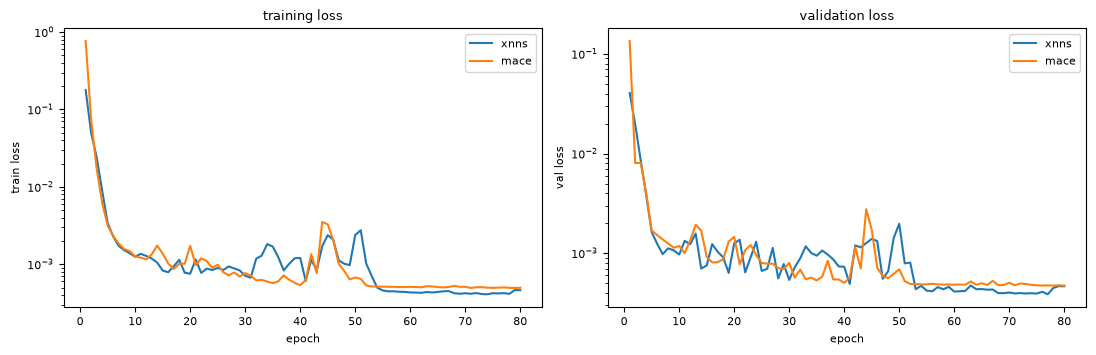

training time:  xnns 211s   mace 172s


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ep = range(1, EPOCHS + 1)
ax[0].plot(ep, hist_xnns["train"], label="xnns"); ax[0].plot(ep, hist_mace["train"], label="mace")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].legend(); ax[0].set_title("training loss")
ax[1].plot(ep, hist_xnns["val"], label="xnns"); ax[1].plot(ep, hist_mace["val"], label="mace")
ax[1].set_yscale("log"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val loss"); ax[1].legend(); ax[1].set_title("validation loss")
plt.tight_layout(); plt.savefig("argon_loss_curves.png", dpi=120); plt.show()
print(f"training time:  xnns {t_xnns:.0f}s   mace {t_mace:.0f}s")

## 5. Evaluate both trained models on the held-out test set

Identical evaluation for each: predict energy + forces (autograd) on all 50 test
configurations and compute per-atom energy and force errors.

In [11]:
def eval_xnns(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, i in zip(test_structs, range(len(xnns_test))):
        out = model(xnns_test[i].to(DEVICE))
        Ep.append(float(out["energy"].detach())); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(out["forces"].detach().cpu().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def eval_mace(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, d in zip(test_structs, mace_test):
        b = next(iter(DL([d], batch_size=1))).to(DEVICE)
        out = model(b.to_dict(), training=False, compute_force=True)
        Ep.append(float(out["energy"].detach())); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(out["forces"].detach().cpu().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def metrics(EpErNa, Fp, Fr):
    Ep, Er, na = EpErNa
    e = (Ep - Er) / na * 1000.0; f = (Fp - Fr) * 1000.0
    return dict(e_rmse=np.sqrt((e**2).mean()), e_mae=np.abs(e).mean(),
                f_rmse=np.sqrt((f**2).mean()), f_mae=np.abs(f).mean(),
                Ep=Ep/na, Er=Er/na, Fp=Fp, Fr=Fr)

res_x = metrics(*eval_xnns(trainer.model))
res_m = metrics(*eval_mace(mace_model))

print(f"{'metric':<22}{'xnns':>12}{'original MACE':>16}")
print("-" * 50)
print(f"{'energy RMSE [meV/atom]':<22}{res_x['e_rmse']:>12.2f}{res_m['e_rmse']:>16.2f}")
print(f"{'energy MAE  [meV/atom]':<22}{res_x['e_mae']:>12.2f}{res_m['e_mae']:>16.2f}")
print(f"{'force  RMSE [meV/Å]':<22}{res_x['f_rmse']:>12.2f}{res_m['f_rmse']:>16.2f}")
print(f"{'force  MAE  [meV/Å]':<22}{res_x['f_mae']:>12.2f}{res_m['f_mae']:>16.2f}")

metric                        xnns   original MACE
--------------------------------------------------
energy RMSE [meV/atom]       16.67           16.34
energy MAE  [meV/atom]       16.25           14.12
force  RMSE [meV/Å]           1.99            2.16
force  MAE  [meV/Å]           1.30            1.44


### Side-by-side parity plots

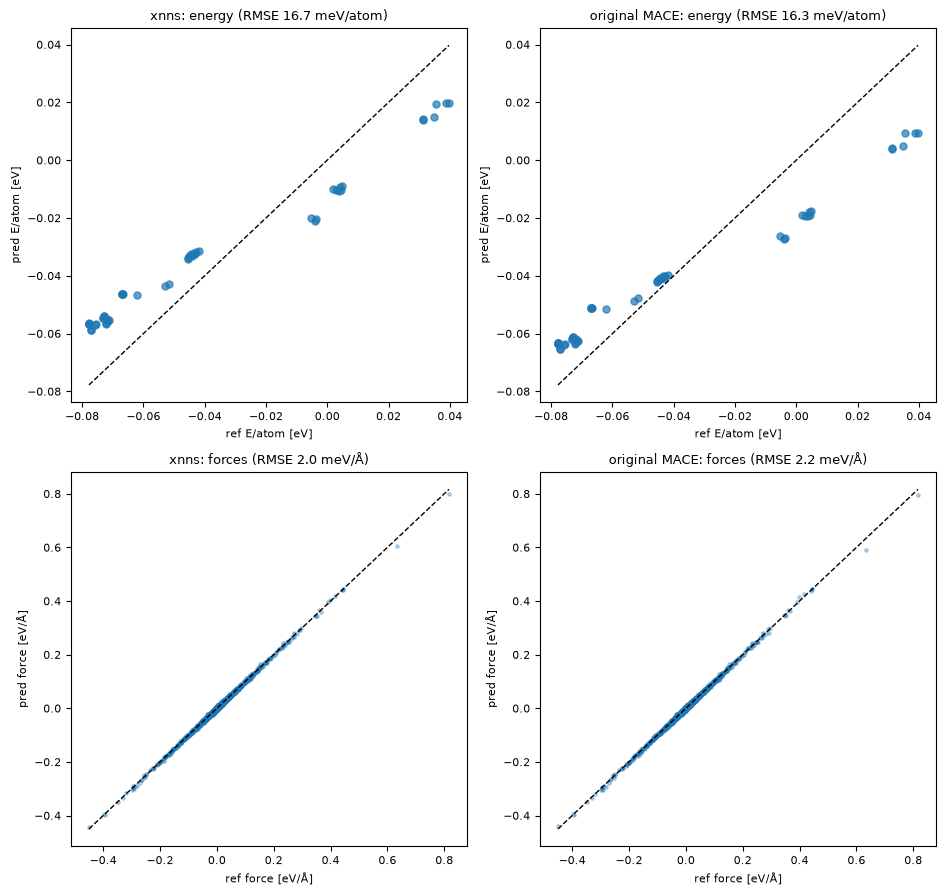

saved argon_parity_xnns_vs_mace.png


In [12]:
fig, ax = plt.subplots(2, 2, figsize=(9.5, 9))
rng = np.random.default_rng(0)
idx = rng.choice(res_x["Fr"].size, size=4000, replace=False)
for col, (res, name) in enumerate([(res_x, "xnns"), (res_m, "original MACE")]):
    a0 = ax[0, col]
    lim = [min(res["Er"].min(), res["Ep"].min()), max(res["Er"].max(), res["Ep"].max())]
    a0.plot(lim, lim, "k--", lw=1); a0.scatter(res["Er"], res["Ep"], s=26, alpha=0.7)
    a0.set_xlabel("ref E/atom [eV]"); a0.set_ylabel("pred E/atom [eV]")
    a0.set_title(f"{name}: energy (RMSE {res['e_rmse']:.1f} meV/atom)")
    a1 = ax[1, col]
    fr, fp = res["Fr"].ravel()[idx], res["Fp"].ravel()[idx]
    lim = [min(fr.min(), fp.min()), max(fr.max(), fp.max())]
    a1.plot(lim, lim, "k--", lw=1); a1.scatter(fr, fp, s=6, alpha=0.3)
    a1.set_xlabel("ref force [eV/Å]"); a1.set_ylabel("pred force [eV/Å]")
    a1.set_title(f"{name}: forces (RMSE {res['f_rmse']:.1f} meV/Å)")
plt.tight_layout(); plt.savefig("argon_parity_xnns_vs_mace.png", dpi=120); plt.show()
print("saved argon_parity_xnns_vs_mace.png")

## 6. `xnns` ASE calculator (deployment)

`xnns` ships an ASE `Calculator` for the trained model.

In [13]:
from ase import Atoms
from xnns.common.deploy import XNNSCalculator

s = test_structs[0]
atoms = Atoms(numbers=s["atomic_numbers"], positions=s["pos"], cell=s["cell"], pbc=True)
atoms.calc = XNNSCalculator(trainer.model.to("cpu"), cutoff=CUTOFF)
print(f"ASE single point: E = {atoms.get_potential_energy():.4f} eV "
      f"({atoms.get_potential_energy()/len(atoms)*1000:.1f} meV/atom) | "
      f"max|F| = {np.abs(atoms.get_forces()).max():.4f} eV/Å")
print(f"reference       : E = {s['energy']:.4f} eV")

ASE single point: E = -22.5679 eV (-56.4 meV/atom) | max|F| = 0.0867 eV/Å
reference       : E = -31.0395 eV


## Summary: every stage compared

| stage | result |
|---|---|
| **Data → graphs** | xnns and `mace` neighbour lists give the **identical edge set** (same counts, same lengths) |
| **Model build** | identical architecture; parameter counts match except xnns's 200-entry `atom_ref` table (E0) |
| **Same function?** | transplanting weights gives **identical E and F on periodic Argon** (float32 round-off; ~1e-13 in float64) |
| **Training** | same data / loss / optimiser / schedule → **comparable loss curves** and final losses |
| **Test accuracy** | energy and force RMSE/MAE **agree** between the two implementations |

<br>

> **Bug found & fixed while building this notebook.** The reference periodic
> neighbour-list stored the cell-shift with a sign inconsistent with
> `AtomicGraph.edge_vectors`, so cross-boundary edges got displacement lengths far
> beyond the cutoff and were silently zeroed by the envelope; i.e. periodic
> systems were trained as if non-periodic. The one-line fix (negate the stored
> shift) is in `xnns/data/neighborlist.py`, guarded by `tests/test_neighborlist.py`
> (xnns edge lengths now match ASE exactly). Every result above uses the fix.

The `xnns` MACE is a faithful, dependency-light (only `e3nn`) re-implementation of
the original MACE: it not only matches block-by-block (notebook 01) but delivers an
**equivalent end-to-end training/testing pipeline** on realistic Argon data. The
small residual differences in trained metrics come only from independent random
initialisation and data shuffling; set the transplant before training (Section 3b)
to start both from identical weights if exact-match training curves are desired.

`REF_stress` is also present in the data; periodic stress training can be enabled
with `compute_stress=True` / non-zero `stress_weight` (same autograd machinery on
both sides).